In [2]:
%pip install -q requests pydantic python-dotenv pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [40]:
import os, re, sys, json, time, ast, operator, subprocess
from pathlib import Path
from dataclasses import dataclass, field
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field, ValidationError

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass
try:
    from kaggle_secrets import UserSecretsClient
    os.environ.setdefault("OPENROUTER_API_KEY", UserSecretsClient().get_secret("OPENROUTER_API_KEY"))
except Exception:
    pass
assert os.getenv("OPENROUTER_API_KEY"), "нет ключа: положите его в .env рядом с ноутбуком или в Kaggle Secrets"

CHAT_URL = "https://openrouter.ai/api/v1/chat/completions"
HEADERS = {"Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}",
           "HTTP-Referer": "https://postypashki.ru", "X-Title": "agents-course-seminar01"}
MODELS = {"cheap": "openai/gpt-4o-mini", "mid": "anthropic/claude-haiku-4.5", "strong": "anthropic/claude-sonnet-4.6"}
COLORS = {"violet": "#5436A3", "amber": "#F09000", "teal": "#00838F", "red": "#C43C3C", "grey": "#787882"}
DATA = Path("data")
TRACES, IMG = Path("traces"), Path("img")
TRACES.mkdir(exist_ok=True)
IMG.mkdir(exist_ok=True)

In [41]:
@dataclass
class Ledger:
    calls: list = field(default_factory=list)

    def add(self, tag, model, usage, seconds=0.0):
        p, c = usage.get("prompt_tokens", 0), usage.get("completion_tokens", 0)
        cost = usage.get("cost") or 0.0
        self.calls.append({"tag": tag, "model": model.split("/")[-1], "prompt": p, "completion": c,
                           "cost": cost, "seconds": round(seconds, 2)})
        return cost

    @property
    def total(self):
        return sum(c["cost"] for c in self.calls)

    def table(self):
        df = pd.DataFrame(self.calls)
        return df.groupby(["tag", "model"]).agg(calls=("cost", "size"), prompt=("prompt", "sum"),
                                                completion=("completion", "sum"), cost=("cost", "sum"),
                                                seconds=("seconds", "sum")).round(5)

ledger = Ledger()

In [42]:
def post_with_retry(body, attempts=3):
    for attempt in range(attempts):
        r = requests.post(CHAT_URL, json=body, headers=HEADERS, timeout=120)
        if r.status_code == 200:
            return r.json()
        if r.status_code in (429, 500, 502, 503) and attempt < attempts - 1:
            time.sleep(1.5 * (attempt+1))
            continue
        raise RuntimeError(f"HTTP {r.status_code} : {r.text[:5000]}")

In [43]:
def chat(messages, model, tools=None, tag="chat", temperature=None):
    body = {"model": model, "messages": messages, "usage": {"include": True}}
    if tools:
        body["tools"] = tools
        body["tool_choice"] = "auto"
    if temperature is not None:
        body["temperature"] = temperature
    started = time.perf_counter()
    data = post_with_retry(body)
    ledger.add(tag, model, data.get("usage") or {}, time.perf_counter() - started)
    return data["choices"][0]["message"]

In [44]:
class Answer(BaseModel):
    reasoning: str = Field(description="ход решения в два-три предложения")
    final: str = Field(description="только итоговый ответ: число или короткая фраза")

SCHEMA_PROMPT = "Отвечай строго одним JSON-объектом по этой схеме, без текста вокруг, строки в одну линию, без лишних отступов, \t, \n:\n{schema}"

def json_from(text):
    m = re.search(r"\{.*\}", text or "", re.S)
    if not m:
        raise ValueError("в ответе нет JSON")
    return json.loads(m.group(0), strict=False)

In [45]:
def ask_structured(question, model, schema=Answer, attempts=3):
    messages = [
        {"role": "system", "content": SCHEMA_PROMPT.format(schema=json.dumps(schema.model_json_schema(), ensure_ascii=False))},
        {"role": "user", "content": question}
    ]
    for _ in range(attempts):
        msg = chat(messages, model, tag="struct")
        try:
            return schema.model_validate(json_from(msg["content"]))
        except (ValidationError, ValueError) as e:
            messages += [msg, {"role": "user", "content": f"Ответ не прошел проверку на структуру: {e}. Верни ответ по строгой JSON схеме"}]
    raise ValueError("Модель не справилась")

In [46]:
def load_tasks(name):
    return [json.loads(line) for line in (DATA / name).read_text(encoding="utf-8").splitlines() if line.strip()]

task = load_tasks("fresh.jsonl")
print(len(task), list(task[0].keys()))

59 ['id', 'source', 'question', 'answer', 'evidence', 'page', 'url', 'sonnet_answer', 'agent_ok']


In [47]:
class Numeric(BaseModel):
    final: float = Field(description="ответ числом")

calls_before = len(ledger.calls)
try:
    result = ask_structured("Какой год основания франции", MODELS["cheap"], Numeric)
except ValueError as e:
    result = e
print("вызовов потрачено:", len(ledger.calls) - calls_before, "| результат:", result)

вызовов потрачено: 1 | результат: final=843.0


In [48]:
def normalize(text):
    text = re.sub(r"[^\w\s]", " ", str(text).lower().replace(",", ""))
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    return " ".join(text.split())

def is_correct(task, answer):
    return normalize(task["answer"]) in normalize(answer)

def summary(config, model, n, correct, cost, steps, seconds=0.0):
    return {"config": config, "model": model.split("/")[-1], "n": n, "accuracy": round(correct / n, 2),
            "cost_per_task": round(cost / n, 5), "cost_per_correct": round(cost / correct, 5) if correct else float("inf"),
            "avg_steps": round(steps, 2), "avg_seconds": round(seconds, 1)}

def compare_models(tasks, models):
    rows = []
    for name, model in models.items():
        before, correct, started = ledger.total, 0, time.perf_counter()
        for task in tasks:
            try:
                correct += is_correct(task, ask_structured(task["question"], model).final)
            except Exception:
                pass
        rows.append(summary("без инструментов, JSON", model, len(tasks), correct, ledger.total - before, 1,
                            (time.perf_counter() - started) / len(tasks)))
    return pd.DataFrame(rows)

def compare_chart(df):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
    axes[0].bar(df["model"], df["accuracy"] * 100, color=COLORS["violet"])
    axes[0].set_ylabel("доля верных, %")
    axes[0].set_ylim(0, 105)
    axes[1].bar(df["model"], df["cost_per_correct"] * 100, color=COLORS["amber"])
    axes[1].set_ylabel("цена верного ответа, центы")
    axes[2].bar(df["model"], df["avg_seconds"], color=COLORS["teal"])
    axes[2].set_ylabel("секунд на задачу")
    for ax in axes:
        ax.tick_params(axis="x", labelrotation=12)
        ax.grid(alpha=0.3, axis="y")
    fig.tight_layout()
    return fig

In [49]:
TOOLS = {}

def register(fn, args_model, description):
    TOOLS[fn.__name__] = {"fn": fn, "args": args_model, "schema": {"type": "function", "function": {
        "name": fn.__name__, "description": description, "parameters": args_model.model_json_schema()}}}

OPS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul, ast.Div: operator.truediv,
       ast.Pow: operator.pow, ast.USub: operator.neg, ast.Mod: operator.mod}

def evaluate(node):
    if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
        return node.value
    if isinstance(node, ast.BinOp) and type(node.op) in OPS:
        return OPS[type(node.op)](evaluate(node.left), evaluate(node.right))
    if isinstance(node, ast.UnaryOp) and type(node.op) in OPS:
        return OPS[type(node.op)](evaluate(node.operand))
    raise ValueError("допустимы только числа и арифметика")

class CalcArgs(BaseModel):
    expr: str = Field(description="арифметическое выражение, например 17*23+5")

def calculator(expr: str) -> str:
    try:
        val = evaluate(ast.parse(expr.replace(",", "."), mode="eval").body)
        return str(int(val)) if float(val).is_integer() else f"{val:.4f}".rstrip("0")
    except Exception as e:
        return f"ошибка вычисления: {e}"

register(calculator, CalcArgs, "Считает арифметическое выражение: числа, скобки, + - * / ** %")
json.dumps(TOOLS["calculator"]["schema"], ensure_ascii=False, indent=1)

'{\n "type": "function",\n "function": {\n  "name": "calculator",\n  "description": "Считает арифметическое выражение: числа, скобки, + - * / ** %",\n  "parameters": {\n   "properties": {\n    "expr": {\n     "description": "арифметическое выражение, например 17*23+5",\n     "title": "Expr",\n     "type": "string"\n    }\n   },\n   "required": [\n    "expr"\n   ],\n   "title": "CalcArgs",\n   "type": "object"\n  }\n }\n}'

In [50]:
SYSTEM = ("Ты решаешь задачи. Если нужно посчитать или найти факт, вызывай инструменты, а не угадывай. "
          "Когда ответ готов, напиши его последней строкой в формате FINAL: <ответ>. "
          "Для числовых задач в FINAL только число, для вопросов о фактах короткая фраза.")

@dataclass
class Run:
    question: str
    answer: str
    steps: int
    messages: list
    cost: float = 0.0
    seconds: float = 0.0

def looped(seen, calls):
    keys = [(c["function"]["name"], c["function"]["arguments"]) for c in calls]
    repeated = any(k in seen for k in keys)
    seen.update(keys)
    return repeated

def finish(model, messages, step):
    del messages[-1]
    messages.append({"role": "user", "content": "Инструменты больше недоступны. Ответь по тому, что уже известно, последней строкой FINAL: <ответ>."})
    msg = chat(messages, model, tag="agent")
    messages.append(msg)
    return msg.get("content") or "", step + 1

In [51]:
def run_tool(call):
    name = call["function"]["name"]

    try:
        spec = TOOLS[name]
        args = spec["args"].model_validate_json(call["function"]["arguments"])
        result = spec["fn"](**args.model_dump())
    except Exception as e:
        result = f"НЕ удалось вызвать инструмент {name}: {e}"
    return {"role": "tool", "tool_call_id" : call["id"], "content": str(result)[:2000]}


In [52]:
def agent_loop(messages, model, tool_names, max_steps):
    seen = set()
    for step in range(1, max_steps + 1):
        msg = chat(messages, model, tools=[TOOLS[n]["schema"] for n in tool_names] or None, tag='agent')
        messages.append(msg)
        calls = msg.get("tool_calls") or []

        if not calls:
            return msg.get("content") or "", step
        if looped(seen, calls) or step == max_steps:
            return finish(model, messages, step)

        messages += [run_tool(c) for c in calls]


In [53]:
def agent(question, model, tool_names, max_steps=8):
    messages = [{"role": "system", "content": SYSTEM}, {"role": "user", "content": question}]
    before, started = ledger.total, time.perf_counter()
    answer, steps = agent_loop(messages, model, tool_names, max_steps)
    return Run(question, answer, steps, messages, ledger.total - before, time.perf_counter() - started)

def show_trace(run):
    for m in run.messages[1:]:
        calls = "; ".join(f"{c['function']['name']}{c['function']['arguments']}" for c in m.get("tool_calls") or [])
        text = " ".join((m.get("content") or "").split())[:180]
        print(f"{m['role']:9s}| {text} {calls}")
    print(f"шагов: {run.steps}, цена: {run.cost * 100:.3f} ¢, время: {run.seconds:.1f} c")

In [54]:
from typing import Literal

WIKI_HEADERS = {"User-Agent": "agents-course-seminar01/1.0 (https://postypashki.ru; educational project)"}

def wiki(params, lang, attempts=3):
    url = f"https://{lang}.wikipedia.org/w/api.php"
    for attempt in range(attempts):
        r = requests.get(url, params={**params, "format": "json"}, headers=WIKI_HEADERS, timeout=15)
        if r.status_code == 200 and r.headers.get("content-type", "").startswith("application/json"):
            return r.json()["query"]
        time.sleep(1.0 + attempt)
    raise RuntimeError(f"Википедия ответила {r.status_code}")

class SearchArgs(BaseModel):
    query: str = Field(description="короткий поисковый запрос: имя, название, термин")
    lang: Literal["en", "ru"] = Field(
        default="en",
        description="en для международных тем, ru для событий в России и СНГ")

class PageFindArgs(BaseModel):
    title: str = Field(description="точное название статьи, например '2026 in France'")
    keywords: str = Field(description="2-4 ключевых слова из вопроса через пробел: имена, числа, термины")
    lang: Literal["en", "ru"] = Field(default="en", description="язык Википедии, как в web_search")

class ExecArgs(BaseModel):
    code: str = Field(description="код на Python; результат надо напечатать через print")

In [55]:

def web_search(query, lang='en'):
    hits = wiki({"action": "query", "list": "search", "srsearch": query, "srlimit": 1}, lang)["search"]

    if not hits:
        return "No data"
    pages = wiki({"action":"query", "prop": "extracts", "explaintext": 1, "exintro": 1, "titles": hits[0]["title"]}, lang)["pages"]
    text = " ".join(next(iter(pages.values())).get("extract", "").split())
    return f"[{hits[0]["title"]}] {text[:2000]}"

In [56]:
def page_find(title, keywords, lang="en"):
    pages = wiki({"action": "query", "prop": "extracts", "explaintext": 1, "titles": title, "redirects": 1}, lang)["pages"]
    text = next(iter(pages.values())).get("extract", "")
    if not text:
        return "no such page"
    words = [w for w in re.findall(r"\w+", keywords.lower()) if len(w) > 2]
    lines = [l.strip() for l in text.splitlines() if l.strip()]
    scored = [(sum(w in l.lower() for w in words), l) for l in lines]
    hits = [l for n, l in sorted(scored, key=lambda x: -x[0]) if n > 0][:6]
    return "\n".join(h[:400] for h in hits[:6]) or "keywords not found on the page"



In [57]:
def python_exec(code: str) -> str:
    try:
        r = subprocess.run([sys.executable, "-I", "-c", code], capture_output=True, text=True, timeout=5)
    except subprocess.TimeoutExpired:
        return "Код превысил 5 сек"
    out = (r.stdout + r.stderr).strip()
    return out[:5000] if out else "Код исполнился но результат пустой"


In [58]:
register(web_search, SearchArgs, "Ищет статью в англоязычной Википедии и возвращает её вступление")
register(page_find, PageFindArgs, "Читает полный текст статьи Википедии и возвращает только строки с ключевыми словами")
register(python_exec, ExecArgs, "Выполняет код на Python в отдельном процессе и возвращает то, что он напечатал")


assert "Tokyo" in page_find("Tokyo", "Shinjuku Shibuya")
assert page_find("Qwxzv nonexistent page 12345", "test") == "no such page"
assert page_find("Tokyo", "qwxzvqwxzv") == "keywords not found on the page"
assert calculator("2+2") == "4"
assert calculator("2**10") == "1024"
assert "ошибка" in calculator("__import__('os')")
assert web_search("Scott Derrickson").startswith("[Scott Derrickson]")
assert web_search("qwxzv 1234567 nonsense") == "No data"
assert python_exec("print(sum(range(10)))") == "45"
assert "ZeroDivisionError" in python_exec("1/0")
assert "Код превысил 5 сек" in python_exec("import time; time.sleep(10)")
"инструменты работают"

'инструменты работают'

In [59]:
def final_answer(text):
    m = re.search(r"FINAL:\s*(.+)", text or "")
    return m.group(1).strip() if m else (text or "").strip()

def run_tasks(tasks, model, tool_names, config):
    folder = TRACES / config / model.split("/")[-1]
    folder.mkdir(parents=True, exist_ok=True)
    rows = []
    for task in tasks:
        try:
            run = agent(task["question"], model, tool_names)
        except Exception as e:
            run = Run(task["question"], f"ошибка: {e}", 0, [])
        ok = is_correct(task, final_answer(run.answer))
        rows.append({"config": config, "model": model.split("/")[-1], "id": task["id"], "source": task["source"],
                     "correct": ok, "steps": run.steps, "tool_calls": sum(m["role"] == "tool" for m in run.messages),
                     "cost": run.cost, "seconds": round(run.seconds, 1), "answer": final_answer(run.answer)[:60], "gold": task["answer"]})
        (folder / f"{task['id']}.json").write_text(json.dumps({"task": task, "answer": run.answer, "correct": ok, "cost": run.cost,
                                                              "messages": run.messages}, ensure_ascii=False, indent=1), encoding="utf-8")
    return pd.DataFrame(rows)

def report(results):
    rows = [summary(config, model, len(df), int(df["correct"].sum()), df["cost"].sum(), df["steps"].mean(), df["seconds"].mean())
            for (config, model), df in results.groupby(["config", "model"])]
    return pd.DataFrame(rows).sort_values("cost_per_task").reset_index(drop=True)

def money_chart(table, path="img/money_quality.png"):
    fig, ax = plt.subplots(figsize=(8, 5))
    for _, r in table.iterrows():
        color = COLORS["red"] if "каскад" in r["config"] else COLORS["amber"] if "sonnet" in r["model"] else COLORS["violet"]
        ax.scatter(r["cost_per_task"] * 100, r["accuracy"] * 100, s=110, color=color)
        ax.annotate(f"{r['config']}\n{r['model']}", (r["cost_per_task"] * 100, r["accuracy"] * 100),
                    fontsize=8, xytext=(6, 4), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("цена задачи, центы (логарифмическая шкала)")
    ax.set_ylabel("доля верных ответов, %")
    ax.grid(alpha=0.3)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

def steps_chart(results):
    g = results.groupby("config").agg(steps=("steps", "mean"), tool_calls=("tool_calls", "mean"), seconds=("seconds", "mean"))
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    g[["steps", "tool_calls"]].plot.bar(ax=axes[0], color=[COLORS["violet"], COLORS["teal"]], rot=12)
    axes[0].set_ylabel("в среднем на задачу")
    g["seconds"].plot.bar(ax=axes[1], color=COLORS["amber"], rot=12)
    axes[1].set_ylabel("секунд на задачу")
    for ax in axes:
        ax.grid(alpha=0.3, axis="y")
        ax.set_xlabel("")
    fig.tight_layout()
    return fig

CONFIGS = {"без инструментов": [], "калькулятор": ["calculator"], "код": ["python_exec"], "поиск": ["web_search"],
           "безымянные": ["tool_a", "tool_b"]}

In [60]:
class Confident(BaseModel):
    reasoning: str = Field(description="ход решения в два-три предложения")
    final: str = Field(description="только итоговый ответ")
    confidence: float = Field(description="честная уверенность в ответе от 0 до 1")

MEMO = {}

def confident_answer(task, model):
    key = (task["id"], model)
    if key not in MEMO:
        before = ledger.total
        try:
            ans = ask_structured(task["question"], model, Confident)
            MEMO[key] = {"final": ans.final, "confidence": ans.confidence, "correct": is_correct(task, ans.final)}
        except Exception:
            MEMO[key] = {"final": "", "confidence": 0.0, "correct": False}
        MEMO[key]["cost"] = ledger.total - before
    return dict(MEMO[key])

In [61]:
def cascade(task, threshold):
    cheap = confident_answer(task, MODELS['cheap'])
    if cheap["confidence"] >= threshold:
        return {**cheap, "escalated": False}
    strong = confident_answer(task, MODELS['strong'])
    return {**strong, "cost": cheap["cost"] + strong["cost"], "escalated": True}


In [62]:
def cascade_sweep(tasks, thresholds):
    rows = []
    for th in thresholds:
        outs = [cascade(t, th) for t in tasks]
        rows.append({"threshold": th, "accuracy": sum(o["correct"] for o in outs) / len(outs),
                     "cost_per_task": sum(o["cost"] for o in outs) / len(outs),
                     "escalated": sum(o["escalated"] for o in outs) / len(outs)})
    df = pd.DataFrame(rows)
    df["cost_per_correct"] = df["cost_per_task"] / df["accuracy"].replace(0, float("nan"))
    return df.round(5)

def cascade_chart(df):
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.plot(df["cost_per_task"] * 100, df["accuracy"] * 100, marker="o", color=COLORS["red"])
    for _, r in df.iterrows():
        ax.annotate(f"порог {r['threshold']}, наверх {r['escalated']:.0%}", (r["cost_per_task"] * 100, r["accuracy"] * 100),
                    xytext=(6, -12), textcoords="offset points", fontsize=8)
    ax.set_xlabel("цена задачи, центы")
    ax.set_ylabel("доля верных, %")
    ax.grid(alpha=0.3)
    return fig

def confidence_chart(tasks, model):
    df = pd.DataFrame([confident_answer(t, model) for t in tasks])
    fig, ax = plt.subplots(figsize=(6.5, 3.4))
    ax.hist(df[df["correct"]]["confidence"], bins=10, range=(0, 1), alpha=0.7, color=COLORS["teal"], label="верные")
    ax.hist(df[~df["correct"]]["confidence"], bins=10, range=(0, 1), alpha=0.7, color=COLORS["red"], label="неверные")
    ax.set_xlabel("заявленная уверенность")
    ax.set_ylabel("задач")
    ax.legend()
    ax.grid(alpha=0.3)
    return fig

In [63]:
tasks = task[:60]

results = pd.concat([
    run_tasks(tasks, MODELS["strong"], [], "strong_no_tools"),
    run_tasks(tasks, MODELS["cheap"], [], "cheap_no_tools"),
    run_tasks(tasks, MODELS["cheap"], ["web_search", "calculator", "python_exec"], "cheap_search"),
    run_tasks(tasks, MODELS["cheap"], ["web_search", "page_find", "calculator", "python_exec"], "cheap_search_page"),
    run_tasks(tasks, MODELS["mid"], ["web_search", "page_find", "calculator", "python_exec"], "mid_search_page"),
])
df = report(results)
print(df, f"\nвсего потрачено: ${ledger.total:.2f}")

              config              model   n  accuracy  cost_per_task  \
0     cheap_no_tools        gpt-4o-mini  59      0.05        0.00004   
1       cheap_search        gpt-4o-mini  59      0.27        0.00060   
2  cheap_search_page        gpt-4o-mini  59      0.42        0.00067   
3    strong_no_tools  claude-sonnet-4.6  59      0.05        0.00235   
4    mid_search_page   claude-haiku-4.5  59      0.56        0.01868   

   cost_per_correct  avg_steps  avg_seconds  
0           0.00086       1.00          2.0  
1           0.00221       4.42         13.1  
2           0.00158       4.37         12.6  
3           0.04625       1.00          4.1  
4           0.03340       4.32         15.5   
всего потрачено: $1.32


In [64]:
def money_chart(table, path="img/money_quality.png"):
    fig, ax = plt.subplots(figsize=(8, 5))
    for _, r in table.iterrows():
        color = COLORS["red"] if "каскад" in r["config"] else COLORS["amber"] if "sonnet" in r["model"] else COLORS["violet"]
        ax.scatter(r["cost_per_task"] * 100, r["accuracy"] * 100, s=110, color=color)
        ax.annotate(f"{r['config']}\n{r['model']}", (r["cost_per_task"] * 100, r["accuracy"] * 100),
                    fontsize=8, xytext=(6, 4), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("цена задачи, центы (логарифмическая шкала)")
    ax.set_ylabel("доля верных ответов, %")
    ax.grid(alpha=0.3)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

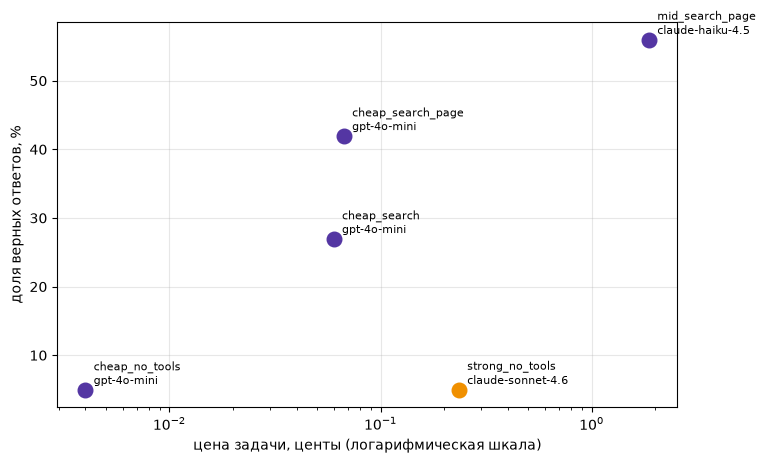

In [65]:
fig = money_chart(df)
fig.savefig(IMG / "money_chart.png", dpi=150, bbox_inches="tight")